<a href="https://colab.research.google.com/github/gravity102424/ESAA/blob/main/ESAA_OB_week09_2_CNN(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5.3 전이 학습

일반적으로 합성곱 신경망 기반의 딥러닝 모델을 제대로 훈련시키려면 많은 양의 데이터가 필요하다. 그런데 충분히 큰 데이터셋을 얻는 것은 많은 돈과 시간이 필요하므로 쉽지 않다.

이러한 현실적인 어려움을 해결한 것이 전이 학습이다. 전이 학습이란 이미지넷처럼 아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것을 의미한다. 이때 아주 큰 데이터셋을 사용하여 훈련된 모델을 사전 훈련된 모델이라고 한다. 결과적으로 비교적 작은 수의 데이터를 가지고도 우리가 원하는 과제를 해결할 수 있다.

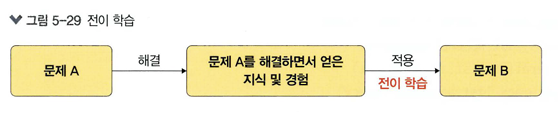

전이 학습을 위한 방법으로는 특성 추출과 미세 조정 기법이 있다.

## 5.3.1 특성 추출 기법

특성 추출은 ImageNet 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만든다. 즉, 학습할 때는 마지막 완전연결층(이미지의 카테고리를 결정하는 부분)만 학습하고 나머지 계층들은 학습되지 않도록 한다.

특성 추출은 이미지 분류를 위해 두 부분으로 구성된다.

* 합성곱층: 합성곱층과 풀링층으로 구성
* 데이터 분류기(완전연결층): 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층(가중치 고정)에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킨다.

여기에서 사용 가능한 이미지 분류 모델은 다음과 같다.

* Xception
* Inception V3
* ResNet50
* VGG16
* VGG19
* MobileNet

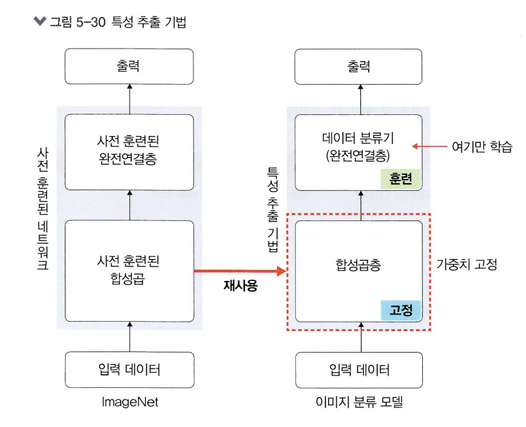

특성 추출에 대해 예시를 진행하기에 앞서 필요한 라이브러리를 설치한다.



```
pip install opencv-python
```



OpenCV는 Open Source Computer Vision Library의 약어로 오픈 소스 컴퓨터 비전 라이브러리다.

먼저 필요한 모든 라이브러리를 호출한다.

In [2]:
!pip install opencv-python

In [5]:
import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [7]:
!git clone https://github.com/gilbutITbook/080289.git

Cloning into '080289'...
remote: Enumerating objects: 2278, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 2278 (delta 1), reused 0 (delta 0), pack-reused 2273 (from 2)
Receiving objects: 100% (2278/2278), 330.30 MiB | 35.57 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Updating files: 100% (2591/2591), done.


In [8]:
# 예제에서 사용할 이미지 데이터에 대한 전처리 방법을 정의한다.

data_path =  '080289/chap05/data/catanddog/train'

transform = transforms.Compose(
    [
        transforms.Resize([256, 256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)
train_dataset = torchvision.datasets.ImageFolder(
    data_path,
    transform = transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


1. torchvision.transform은 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 변환해 준다. 이때 사용되는 파라미터는 다음과 같다.



```
transform = transform.Compose([transforms.Resize([256, 256]),
transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(),
transforms.ToTensor()])
```

2. datasets.ImageFolder는 데이터로더가 데이터를 불러올 대상(혹은 경로)과 방법(혹은 전처리)을 정의하며, 사용하는 파라미터는 다음과 같다.



```
train_dataset = torchvision.datasets.ImageFolder(data_path, transform=transform)
```
3. 데이터로더는 데이터를 불러오는 부분으로 앞에서 정의한 ImageFolder(train_dataset)을 데이터로더에 할당하는데, 이때 한 번 불러올 데이터양을 결정하는 batch_size를 지정한다. 또한, 추가적으로 데이터를 무작위로 섞을 것인지도 설정한다. 데이터로더에서 사용하는 파라미터는 다음과 같다.



```
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, num_workers=8, shuffle=True)
```
다음은 train_dataset에 포함된 데이터의 개수를 출력한 결과이다.

385

개와 고양이 이미지 데이터는 https://www.kaggle.com/c/dogs-vs-cats/data에서 내려받았지만, 전체 이미지를 사용할 경우 CPU에 과부하가 발생하여 일부 이미지만 사용했다.




/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


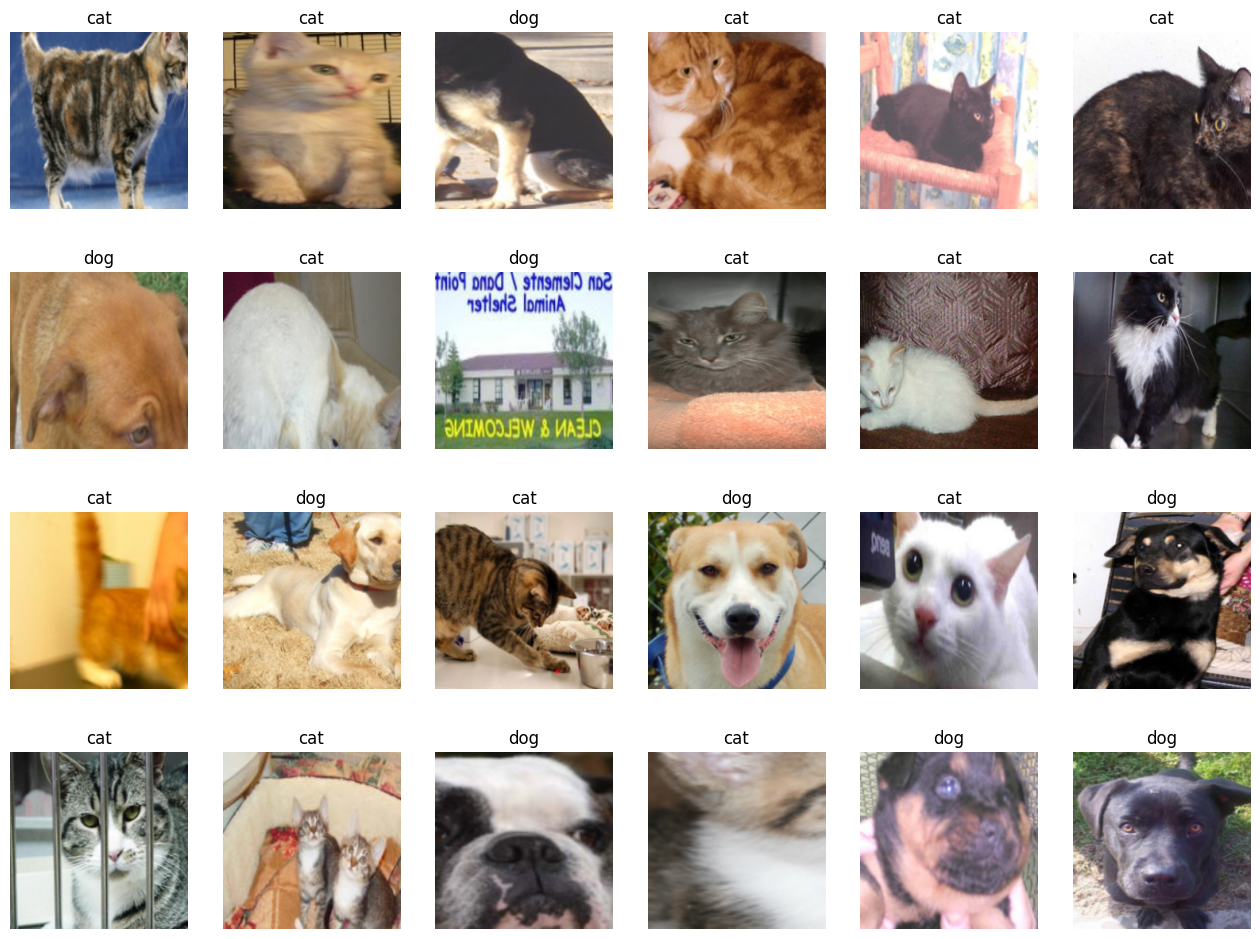

In [10]:
# 학습에 사용될 이미지 출력
import numpy as np

samples, labels = next(iter(train_loader)) # 1
classes = {0:'cat', 1:'dog'} # 개와 고양이에 대한 클래스로 구성
fig = plt.figure(figsize=(16,24))
for i in range(24): # 24개의 이미지 데이터 출력
  a = fig.add_subplot(4,6,i+1)
  a.set_title(classes[labels[i].item()]) # 레이블 정보(클래스)를 함께 출력
  a.axis('off')
  a.imshow(np.transpose(samples[i].numpy(), (1,2,0))) # 2
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

1. 반복자(iterator, for 구문과 같은 효과)를 사용하려면 iter()와 next()가 필요하다. iter()는 전달된 데이터의 반복자를 꺼내 반환하며, next()는 그 반복자가 다음에 출력해야 할 요소를 반환한다. 앞의 코드에서 반복자는 train_loader가 되기 때문에 train_loader에서 samples와 labels의 값을 순차적으로 꺼내서 저장한다. 간단히 정리하면 train_loader에서 데이터를 하나씩 꺼내 오겠다는 의미다.

2. np.transpose는 행과 열을 바꿈으로써 행렬의 차원을 바꾸어 준다.



In [11]:
# ResNet18 모델 내려받기

resnet18 = models.resnet18(pretrained=True)
# pretrained=True는 사전 학습된 가중치를 사용하겠다는 의미

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 105MB/s]


## ResNet18
ResNet18은 50개의 계층으로 구성된 합성곱 신경망이다. lmageNet 데이터베이스의 100만 개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공하고 있다. 하지만 ResNet18은 입력 제약이 매우 크고, 충분한 메모리(RAM)가 없으면 학습 속도가 느렬 수 있는 단점이 있다.

## 사전 훈련된 모델
파이토치는 다음과 같은 방법으로 무작위의 가중치로 모델을 구성할 수 있다.

In [12]:
# import torchvision.models as models
# resnet18 = models .resnet18()
# alexnet = models .alexnet()
# vgg16 = models .vgg16()
# squeezenet = models .squeezenet1_0()
# densenet = models .densenet161()
# inception = models .inception_v3()
# googlenet = models .googlenet()
# shufflenet = models .shufflenet_v2_x1_0()
# mobilenet_v2 = models .mobilenet_v2()
# mobilenet_v3_large = models .mobilenet_v3_large()
# mobilenet_v3_small = models .mobilenet_v3_small()
# resnext50_32x4d = models .resnext50_32x4d()
# wide_resnet50_2 = models .wide_resnet50_2()
# mnasnet = models .mnasnet1_0()

또한， 다음과 같은 방법을 이용하여 사전 학습된 모델(사전 학습된 모델의 가중치 값)을 사용할 수 있다. 다음의 모델들이 사용하는 것과 같이 pretrained=True로 설정하여 시용하면 된다.

In [13]:
# import torchvision.models as models
# resnet18 = models .resnet18(pretrained=True )
# alexnet = models .alexnet(pretrained=True )
# squeezenet = models .squeezenet1_피 (pretrained=True )
# vgg16 = models .vgg16(pretrained=True )
# densenet = models .densenet161(pretrained=True )
# inception = models .inception_v3(pretrained=True )
# googlenet = models .googlenet(pretrained=True )
# shufflenet = models .shufflenet_v2_x1_θ( pretrained=True)
# mobilenet_v2 = models .mobilenet_v2( pretrained=True )
# mobilenet_v3_large = models .mobilenet_v3_large(pretrained=True )
# mobilenet_v3_small = models .mobilenet_v3_small(pretrained=True )
# resnext50_32x4d = models .resnext50_32x4d( pretrained=True )
# wide_resnet50_2 = models .wide_resnet50_2(pretrained=True )
# mnasnet = models .mnasnet1_0( pretrained=True )

다음은 내려받은 ResNet18의 합성곱층을 사용하되 파라미터에 대해서는 학습을 하지 않도록 고정시킨다.

In [14]:
def set_parameter_requires_grad(model, feature_extracting=True):
  if feature_extracting:
    for param in model.parameters():
      param.requires_grad = False # 1

set_parameter_requires_grad(resnet18)

1. 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타낸다. 즉, 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정한다. 이때 모델의 일부는 합성곱층(convolutïonal layer)과 풀링(pooling)층을 의미한다.

내려받은 ResNet18의 마지막 부분에 완전연결층을 추가한다. 추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용된다.


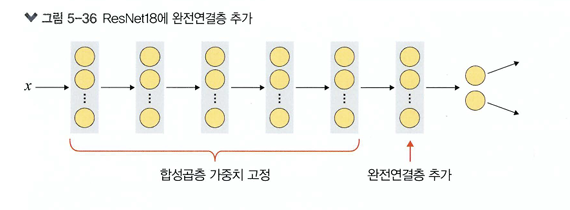

In [15]:
# ResNet18에 완전연결층 추가
resnet18.fc = nn.Linear(512, 2) # 2는 클래스가 두 개라는 의미

In [16]:
# 모델의 파라미터 값 확인
for name, param in resnet18.named_parameters():# model.named_parameters()는 모델에 접근하여 파라미터 값들을 가져올 때 사용
  if param.requires_grad:
    print(name, param.data)

fc.weight tensor([[ 0.0360,  0.0260, -0.0203,  ..., -0.0259,  0.0038, -0.0001],
        [ 0.0139,  0.0003,  0.0071,  ...,  0.0224,  0.0182, -0.0238]])
fc.bias tensor([-0.0255,  0.0410])


In [17]:
# 모델 객체 생성 및 손실 함수 정의

model = models.resnet18(pretrained=True)

for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn.Linear(512,2)
for param in model.fc.parameters():
  param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [18]:
# 모델 학습을 위한 함수 생성
def train_model(model, dataloaders, criterion, optimizer, device, num_epochs=13, is_train=True):
  since = time.time() # 컴퓨터의 현재 시각을 구하는 함수
  acc_history = []
  loss_history = []
  best_acc = 0.0

  for epoch in range(num_epochs): # 에포크(13)만큼 반복
    print('Epoch {}/{}'.format(epoch, num_epochs-1))
    print('-' * 10)

    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in dataloaders: # 데이터로더에 전달된 데이터만큼 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      model.to(device)
      optimizer.zero_grad() # 기울기를 0으로 설정
      outputs = model(inputs) # 순전파 학습
      loss = criterion(outputs, labels)
      __, preds = torch.max(outputs, 1)
      loss.backward() # 역전파 학습
      optimizer.step()

      running_loss += loss.item() * inputs.size(0) # 출력 결과와 레이블의 오차를 계산한 결과를 누적하여 저장
      running_corrects += torch.sum(preds == labels.data) # 출력 결과와 레이블이 동일한지 확인한 결과를 누적하여 저장
    epoch_loss = running_loss / len(dataloaders.dataset) # 평균 오차 계산
    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 평균 정확도 계산

    print('Loss: {:.4f} Acc: {:.4f}'.format(epoch_loss, epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    loss_history.append(epoch_loss)
    torch.save(model.state_dict(), os.path.join('080289/chap05/data/catanddog/', '{0:0=2d}.pth'.format(epoch))) # 모델 재사용을 위해 저장해 둡니다.
    print()

  time_elapsed = time.time() - since # 실행 시간(학습 시간)을 계산
  print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))
  return acc_history, loss_history # 모델의 정확도와 오차를 반환

그리고 마지막으로 ResNet18에 추가된 완전연결층은 학습을 하도록 설정한다. 학습을 통해 얻어지는 파라미터를 옵티마이저에 전달해서 최종적으로 모델 학습에 사용한다.

In [19]:
params_to_update = []
for name, param in resnet18.named_parameters():
  if param.requires_grad == True:
    params_to_update.append(param) # 파라미터 학습 결과를 저장
    print("\t", name)
optimizer = optim.Adam(params_to_update) # 학습 결과를 옵티마이저에 전달

	 fc.weight
	 fc.bias


다음은 완전연결층의 어떤 파라미터들이 옵티마이저로 전달되는지를 보여 준다. 다음 결과와 같이 weight와 bias 값들이 업데이트되고 옵티마이저에 전달될 것이다.

In [20]:
# 모델 학습

device = torch.device("cuda" if torch.cuda.is_available() else "cpu" )
criterion = nn.CrossEntropyLoss () # 손실 함수 지정
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion, optimizer, device)

Epoch 0/12
----------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Loss: 0.5740 Acc: 0.7117

Epoch 1/12
----------
Loss: 0.4017 Acc: 0.8364

Epoch 2/12
----------
Loss: 0.3212 Acc: 0.8909

Epoch 3/12
----------
Loss: 0.3083 Acc: 0.8649

Epoch 4/12
----------
Loss: 0.2614 Acc: 0.8987

Epoch 5/12
----------
Loss: 0.2588 Acc: 0.8935

Epoch 6/12
----------
Loss: 0.2710 Acc: 0.8831

Epoch 7/12
----------
Loss: 0.2366 Acc: 0.9013

Epoch 8/12
----------
Loss: 0.2537 Acc: 0.8935

Epoch 9/12
----------
Loss: 0.2473 Acc: 0.8935

Epoch 10/12
----------
Loss: 0.2183 Acc: 0.9117

Epoch 11/12
----------
Loss: 0.1934 Acc: 0.9273

Epoch 12/12
----------
Loss: 0.2553 Acc: 0.8935

Training complete in 8m 55s
Best Acc: 0.927273


모델 훈련을 위해 전달되는 파라미터는 (모델， 학습 데이터， 손실 함수， 옵티마이저， 장치(CPU) 혹은GPU))다.

약 93%로 상당히 높은 정확도를 보여 주고 있다. 훈련 데이터로는 학습이 잘되었다고 할 수 있다. 이제 태스트 용도의 데이터를 이용하여 모델 정확도를 측정해 보아야 한다.

테스트 데이터를 불러와 전처리를 한다.

In [21]:
# 테스트 데이터 호출 및 전처리

test_path = '080289/chap05/data/catanddog/test'

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    ])
test_dataset = torchvision.datasets.ImageFolder(
    root=test_path,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    num_workers=1,
    shuffle=True
)

print (len(test_dataset))

98


태스트용 데이터 준비가 완료되었다. 테스트 데이터 평가를 위한 함수를 생성한다.

In [23]:
def eval_model(model, dataloaders, device):
  since = time.time()
  acc_history = []
  best_acc = 0.0

  saved_models = glob.glob('080289/chap05/data/catanddog/' + '*.pth') # 1
  saved_models.sort() # 불러온 .pth 파일들을 정렬
  print('saved_model', saved_models)

  for model_path in saved_models:
    print('Loading model', model_path)

    model.load_state_dict(torch.load(model_path))
    model.eval()
    model.to(device)
    running_corrects = 0

    for inputs, labels in dataloaders: # 테스트 반복
      inputs = inputs.to(device)
      labels = labels.to(device)

      with torch.no_grad(): # autograd를 사용하지 않겠다는 의미
        outputs = model(inputs) # 데이터를 모델에 적용한 결과를 outputs에 저장

      _, preds = torch.max(outputs.data, 1) # 2
      preds[preds >= 0.5] = 1 # torch.max로 출력된 값이 0.5보다 크면 올바르게 예측
      preds[preds < 0.5] = 0 # torch.max로 출력된 값이 0.5보다 작으면 틀리게 예측
      running_corrects += preds.eq(labels.cpu()).int().sum() # 3

    epoch_acc = running_corrects.double() / len(dataloaders.dataset) # 테스트 데이터의 정확도 계산
    print('Acc: {:.4f}'.format(epoch_acc))

    if epoch_acc > best_acc:
      best_acc = epoch_acc

    acc_history.append(epoch_acc.item())
    print()

  time_elapsed = time.time() - since
  print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
  print('Best Acc: {:4f}'.format(best_acc))

  return acc_history # 계산된 정확도 반환

1. glob은 현재 디렉터리에서 원하는 파일들만 추출하여 가져올 때 사용한다. 즉, '../chap05/data/catanddog/' 경로에서 pth 확장자를 갖는 파일을 가져오라는 의미입니다. pth라는 확장자를 갖는 파일은 훈련 데이터로 모댈을 훈련시킬 때 생성된 파일이다.

2. torch.max는 주어진 텐서 배열의 최멋값이 들어 있는 index를 반환하는 함수이다. 예를 들어 y_pred = [[0.2，0.7, 0.8, 0.4]] 라는 배열에 torch.max(y_pred.data, 1)을 적용한다고 가정해 보자. [8.2，0.7, 0.8, 0.4]의 최멋값은 0.8이 되며 그 인텍스는 2이므로 최종적으로 반환되는 값은 2가 된다.

3. preds.eq(labels)는 preds 배열과 labels가 일치하는지 검사히는 용도로 사용한다. 또한, 뒤에 사용된 .sum()은 모델의 예측 결과와 정답(레이블)이 일치히는 것들의 개수 합을 숫자로 출력한다.

이제 모델 평가 함수에 태스트 데이터를 적용해서 실제로 성능(정확도)을 측정한다.

In [24]:
val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['080289/chap05/data/catanddog/00.pth', '080289/chap05/data/catanddog/01.pth', '080289/chap05/data/catanddog/02.pth', '080289/chap05/data/catanddog/03.pth', '080289/chap05/data/catanddog/04.pth', '080289/chap05/data/catanddog/05.pth', '080289/chap05/data/catanddog/06.pth', '080289/chap05/data/catanddog/07.pth', '080289/chap05/data/catanddog/08.pth', '080289/chap05/data/catanddog/09.pth', '080289/chap05/data/catanddog/10.pth', '080289/chap05/data/catanddog/11.pth', '080289/chap05/data/catanddog/12.pth']
Loading model 080289/chap05/data/catanddog/00.pth
Acc: 0.8061

Loading model 080289/chap05/data/catanddog/01.pth
Acc: 0.9184

Loading model 080289/chap05/data/catanddog/02.pth
Acc: 0.8980

Loading model 080289/chap05/data/catanddog/03.pth
Acc: 0.9184

Loading model 080289/chap05/data/catanddog/04.pth
Acc: 0.8980

Loading model 080289/chap05/data/catanddog/05.pth
Acc: 0.9388

Loading model 080289/chap05/data/catanddog/06.pth
Acc: 0.9082

Loading model 080289/chap05/data/catand

테스트 데이터 역시 94% 정도의 높은 정확도를 보인다. 만약 모벨의 네트워크를 개발자가 직접 구현하고 최적의 파라미터 값을 찾는다면 꽤 오랜 시간이 소요될 것이다. 하지만 사전 훈련된 모델을 사용한다면 손쉽게 모댈을 학습시킬 수 있기 때문에 실무에서도 많이 사용된다.

이제 모텔의 학습 결괴를 시각적으로 살펴보겠다. 먼저 훈련과 테스트 데이터에 대한 정확도이다.

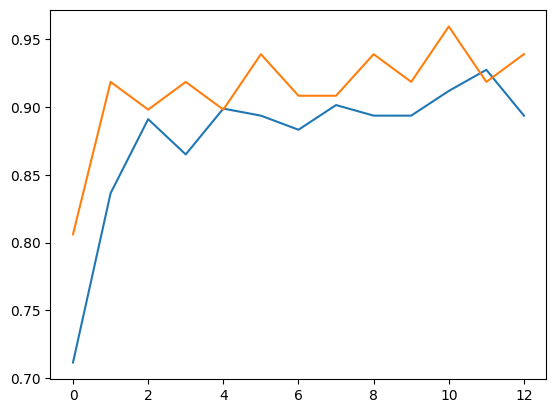

In [25]:
plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

다음 그림은 훈련과 테스트 데이터에 대해 에포크가 진행될 때마다 정확도를 출력한 결과이다. 훈련과 테스트 데이터 모두 에포크가 진행될수록 정확도가 높아지면서 100% 가까워지고 있다. 실제로 더 많은 에포크를 진행한다면 더욱더 100%에 수렴하는 것을 확인할 수 있다.



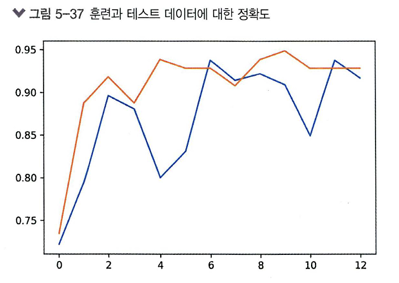

이번에는 오차 정보를 그래프로 살펴보겠다.

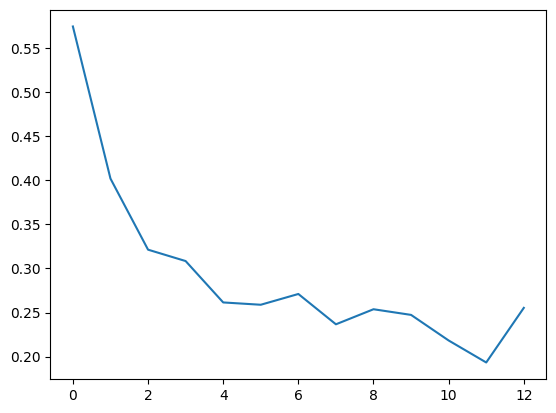

In [26]:
plt.plot(train_loss_hist)
plt.show()

훈련 데이터에 대해 에포크가 진행될 때마다 오차를 출력한 결과이다. 에포크가 진행될수록 오차가 낮아지고 있기 때문에 학습이 잘되었다고 할 수 있다.

단순히 정확도와 오차 정보를 확인하는 것에 머무르지 않고, 실제로 데이터를 잘 예측하는지 살펴보겠다.

먼저 예측된 이미지를 출력하기 위한 전처리 함수를 생성한다.

In [27]:
# 예측 이미지 출력을 위한 전처리 함수
def im_convert(tensor):
  image = tensor.clone().detach().numpy() # 1
  image = image.transpose(1,2,0)
  image = image * (np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
  image = image.clip(0,1) # 2
  return image

1. tensor.clone()은 기존 댄서의 내용을 복사한 텐서를 생성하겠다는 의미이며, detach()는 기 존 텐서에서 기울기가 전파되지 않는 텐서이다. 즉, tensor.clone().detach()는 기존 텐서를 복사한 새로운 텐서를 생성하지만 기울기에 영향을 주지는 않겠다는 의미이다.
다음은 tensor.clone(), tensor.detach(), tensor.clone().detach()를 비교한 표이다.

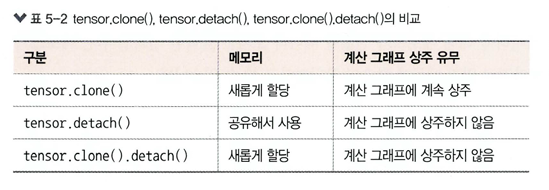

## 계산 그래프
계산 그래프란 게산 과정을 그래프로 나타낸 것이다. 그래프는 여러 개의 노드와 그 노드들을 연결하는 선인 에지로 구성된다.

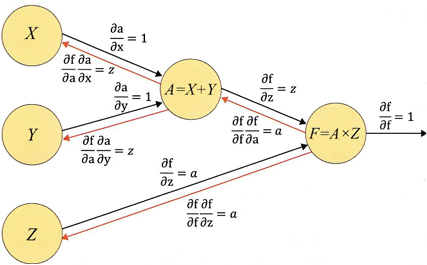

계산 그래프를 사용하면 국소적 계산이 가능하고, 역전파를 통한 미분 계산이 편리하다.

## 연쇄 법칙
두 개 이상의 함수가 결합된 함수. 즉, 합성 함수의 미분법을 연쇄 법칙 혹은 체인룰이라고 한다.

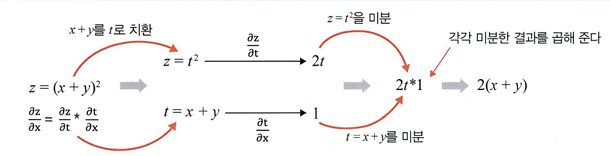


2. clip()은 입력 값이 주어진 범위를 벗어날 때 입력 값을 특정 범위로 제한시커기 위해 사용합니다. 즉, image.clip(0, 1)은 image 데이터를 0과 1 사이의 값으로 제한하겠다는 의미이다.

이제 테스트 데이터셋을 이용하여 실제로도 개와 고양이를 잘 분류하는지 살펴보겠다.

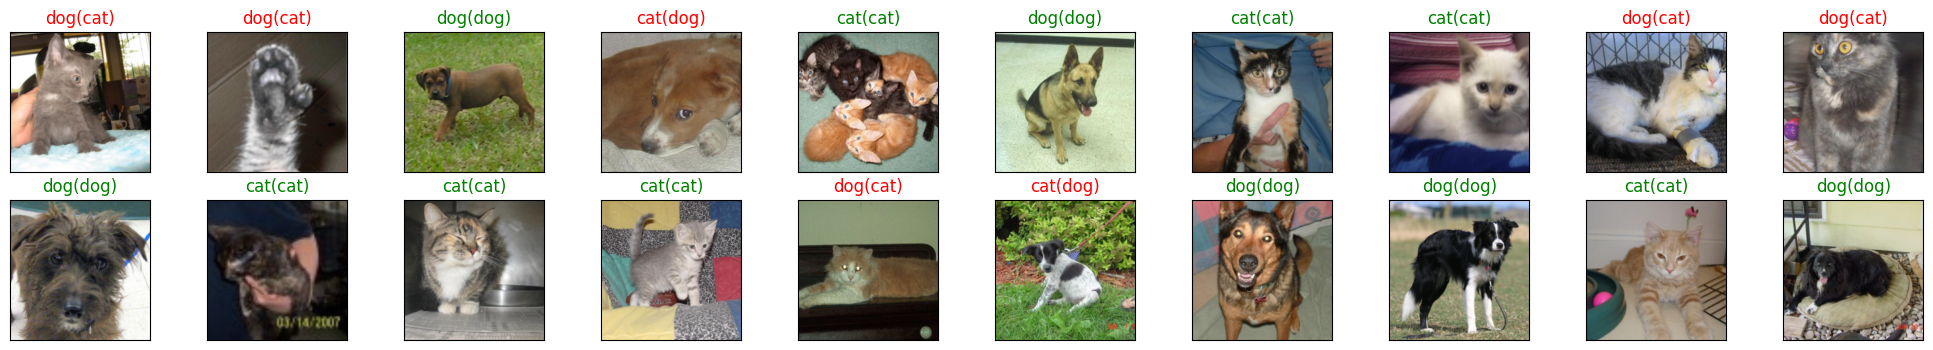

<Figure size 640x480 with 0 Axes>

In [28]:
classes = {0:'cat', 1:'dog'} # 개와 고양이 두 개에 대한 레이블

dataiter = iter(test_loader) # 테스트 데이터셋을 가져옵니다.
images, labels = next(dataiter) # 테스트 데이터셋에서 이미지와 레이블을 분리하여 가져옵니다.
output = model(images)
_, preds = torch.max(output, 1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
  ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[]) # 1
  plt.imshow(im_convert(images[idx])) # 이미지 출력을 위해 im_convert 함수를 적용
  a.set_title(classes[labels[i].item()])
  ax.set_title("{}({})".format(str(classes[preds[idx].item()]), str(classes[labels[idx].item()])), color=("green" if preds[idx]==labels[idx] else 'red')) # 2
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0) # 3

1. add_subplot은 한 화면에 여러 개의 이미지를 담기 위해 사용한다. 이때 사용되는 파라미터는 다음과 같다.
a. 첫번째 파라미터: 행의 수를 의미하는데 이미지를 두줄로 출력한다.

b. 두 번째 파라미터: 열의 수를 의미하는데, 한 줄에 열 개의 이미지를 출력한다.

c. 세 번째 파라미터: 인덱스를 의미하는데 행과 열을 기준으로 순차적으로 이미지를 출력한다.

d. 네 번째 파라미터 : 틱을 삭제하겠다는 의미이다.

2. classes[labels[idx].item()]은 preds[idx].item() 값이 classes로 정의된 '0'과 '1' 중 어떤 값을 갖는지 판별하겠다는 의미이다. 즉, classes[preds[idx].item()] 값이 0이면 고양이, 1이면 개로 출력된다.

3. 다음 그림과 같이 Figure 안에서 서브플롯(다음 그림에서 axes에 해당)의 위치를 조정할 때 시용한다. left, bottom, right, top으로 이미지 위치를 조정합니다. 또한, hspace와 wspace를 사용해서 서브플롯 간의 간격(너비와 높이의 비율)을 조정할 수 있다.

결과를 살펴보니 예측이 정확하지 않은 것을 확인할 수 있다. 훈련 데이터를 더 늘리고, 에포크 횟수도늘려 보면 더 좋은 결과를 얻을수 있을 것이다.

## 5.3.2 미세 조정 기법

미세 조정 기법은 특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이터하여 훈련시키는 방식이다. 특성 추출은 목표 특성을 잘 추출했다는 전제하에 좋은 성능을 낼 수 있다. 특성이 잘못 추출되었다면 미세 조정 기법으로 새로운 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있다. 즉, 사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학습시키는 것이다.

미세 조정 기법은 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모델의 파라미터를 조정하는 기법이다. 미세 조정 과정에서 많은 연산량이 필요하기 때문에 CPU보다는 GPU를 사용하길 권장한다.

미세 조정 기법은 훈련시키려는 데이터셋의 크기와 사전 훈련된 모델에 따라 다음 전략을 세울 수 있다.

* **데이터셋이 크고 사전 훈련된 모델과 유사성이 작을 경우**: 모델 전체를 재학습시킨다. 데이터셋 크기가 크기 때문에 재학습시키는 것이 좋은 전략이다.

* **데이터셋이 크고 사전 훈련된 모델과 유사성이 클 경우**: 합성곱층의 뒷부분(완전연결층과 가까운 부분)과 데이터 분류기를 학습시킨다. 데이터셋이 유사하기 때문에 전체를 학습시키는 것보다는 강한 특징이 나타나는 합성곱층의 뒷부분과 데이터 분류기만 새로 학습하더라도 최적의 성능을 낼 수 있다.

* **데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우**: 합성곱층의 일부분과 데이터 분류기를 학습시킨다. 데이터가 적기 때문에 일부 계층에 미세 조정 기법을 적용한다고 해도 효과가 없을 수 있다. 따라서 합성곱층 중 어디까지 새로 학습시켜야 할지 적당히 설정해 주어야 한다.

* **데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우**: 데이터 분류기만 학습시킨다. 데이터가 적기 때문에 많은 계층에 미세 조정 기법을 적용하면 과적합이 발생할 수 있다. 따라서 최종 데이터 분류기인 완전연결층에 대해서만 미세 조정 기법을 적용한다.

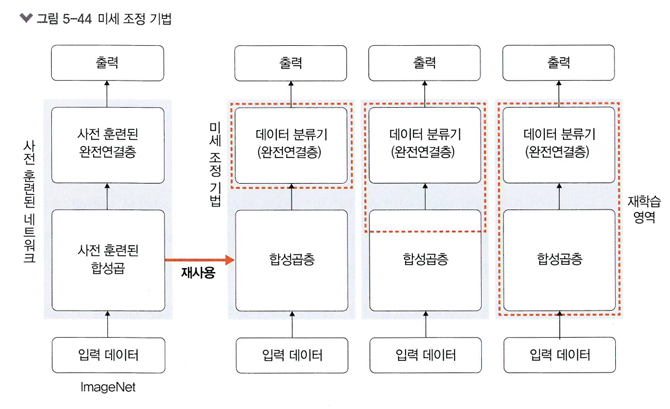

미세 조정은 파라미터 업데이트 과정에서 파라미터에 큰 변화를 주게 되면 과적합 문제가 발생할 수 있기 때문에 정교하고 미세한 파라미터 업데이트가 필요하다.